# Evaluation for ANN with strong arsenic contamination

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.event_detection import build_detector, collect_strong_contamination_paths, split_train_test
from src.event_detection_pipeline.model_io import load_detector, save_detector

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.event_detection_pipeline.evaluation import (
    plot_roc_curve_event_detection,
    plot_chlorine_prediction_quality,
    plot_precision_recall_curve,
)

In [2]:
data_dir = ROOT / 'src' / 'data'
paths = collect_strong_contamination_paths(data_dir)
train_paths, test_paths = split_train_test(paths)

#todo check why there are 7 tests
#todo make a comparison of the best performing ann between the contamination/strong contamination and no contamination datasets

print(f'Loaded {len(paths)} SCADA files')
print(f'Train files: {len(train_paths)} | Test files: {len(test_paths)}')

Loaded 20 SCADA files
Train files: 16 | Test files: 4


In [3]:
print("Test:", len(test_paths))

for path in test_paths:
    print(path.name)

Test: 4
scada_data_strong_cont12.npz
scada_data_strong_cont13.npz
scada_data_strong_cont11.npz
scada_data_strong_cont10.npz


In [4]:
# confusion matrix for event detection
history = 48
# history 48 = 1 day, history 96 = 2 days
epochs = 60
batch_size = 128
learning_rate = 3e-4
dropout = 0.0
weight_decay = 1e-4
early_stopping_patience = 8
max_validation_false_alarm_rate = 0.2
# Held-out test: BA=0.6868, recall=0.5609, FAR=0.1872, precision=0.1851

candidate_hidden_sizes = [
    (32,),
    (64, 32),  # best validation configuration ?
    (128, 64),
    (128, 64, 32),
]

In [5]:
# RUN only if you want to overwrite the current detector performance results

for hidden_sizes in candidate_hidden_sizes:
    candidate_detector = build_detector(
        train_paths,
        history=history,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        hidden_sizes=hidden_sizes,
        dropout=dropout,
        weight_decay=weight_decay,
        early_stopping_patience=early_stopping_patience,
        max_validation_false_alarm_rate=max_validation_false_alarm_rate,
    )

    save_detector(candidate_detector, directory=f"../../results/ANN/detector_strong_{'-'.join(map(str, hidden_sizes))}")


All files saved to /Users/esther/dev/Arsenic-Detection/results/ANN/detector_strong_32/

All files saved to /Users/esther/dev/Arsenic-Detection/results/ANN/detector_strong_64-32/

All files saved to /Users/esther/dev/Arsenic-Detection/results/ANN/detector_strong_128-64/

All files saved to /Users/esther/dev/Arsenic-Detection/results/ANN/detector_strong_128-64-32/


In [6]:
def plot_metrics(result, title_prefix="", chlorine_indices=None):
    
    print("Chlorine indices:", chlorine_indices)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Confusion Matrix
    cm = confusion_matrix(
        result.event_flags.astype(bool),
        result.alarms.astype(bool),
        labels=[False, True],
        normalize="all",
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Event"],
    )
    disp.plot(
        ax=axes[0, 0],
        colorbar=False,
        values_format=".2f",
    )
    axes[0, 0].set_title(f"{title_prefix}Confusion Matrix")

    # 2. Event detection ROC
    plot_roc_curve_event_detection(
        result,
        title=f"{title_prefix}Event Detection ROC",
        ax=axes[0, 1],
    )

    # 3. True chlorine regression quality (ROC would measure event residuals)
    plot_chlorine_prediction_quality(
        result,
        chlorine_indices=chlorine_indices,
        title=f"{title_prefix}Chlorine Prediction Quality",
        ax=axes[1, 0],
    )

    # 4. Precision-Recall curve
    plot_precision_recall_curve(
        result,
        title=f"{title_prefix}Precision-Recall Curve",
        ax=axes[1, 1],
    )

    plt.tight_layout()
    plt.show()
    return fig, axes


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/results/ANN/detector_strong_32/
Results for detector with hidden sizes: 32


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_strong_cont12.npz,0.486842,0.927159,0.544118,0.544118,0.043673,43200.0,76
scada_data_strong_cont13.npz,0.592233,0.941727,0.813333,0.813333,0.047404,1800.0,103
scada_data_strong_cont11.npz,0.706250,0.601457,0.251670,0.251670,0.091797,14400.0,160
scada_data_strong_cont10.npz,0.203774,0.770031,0.843750,0.843750,0.235229,0.0,265


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.497275,0.810094,0.613218,0.613218,0.104526,14850.000000,151.000000
std,0.215205,0.159338,0.276093,0.276093,0.089835,19956.202043,83.677954


Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


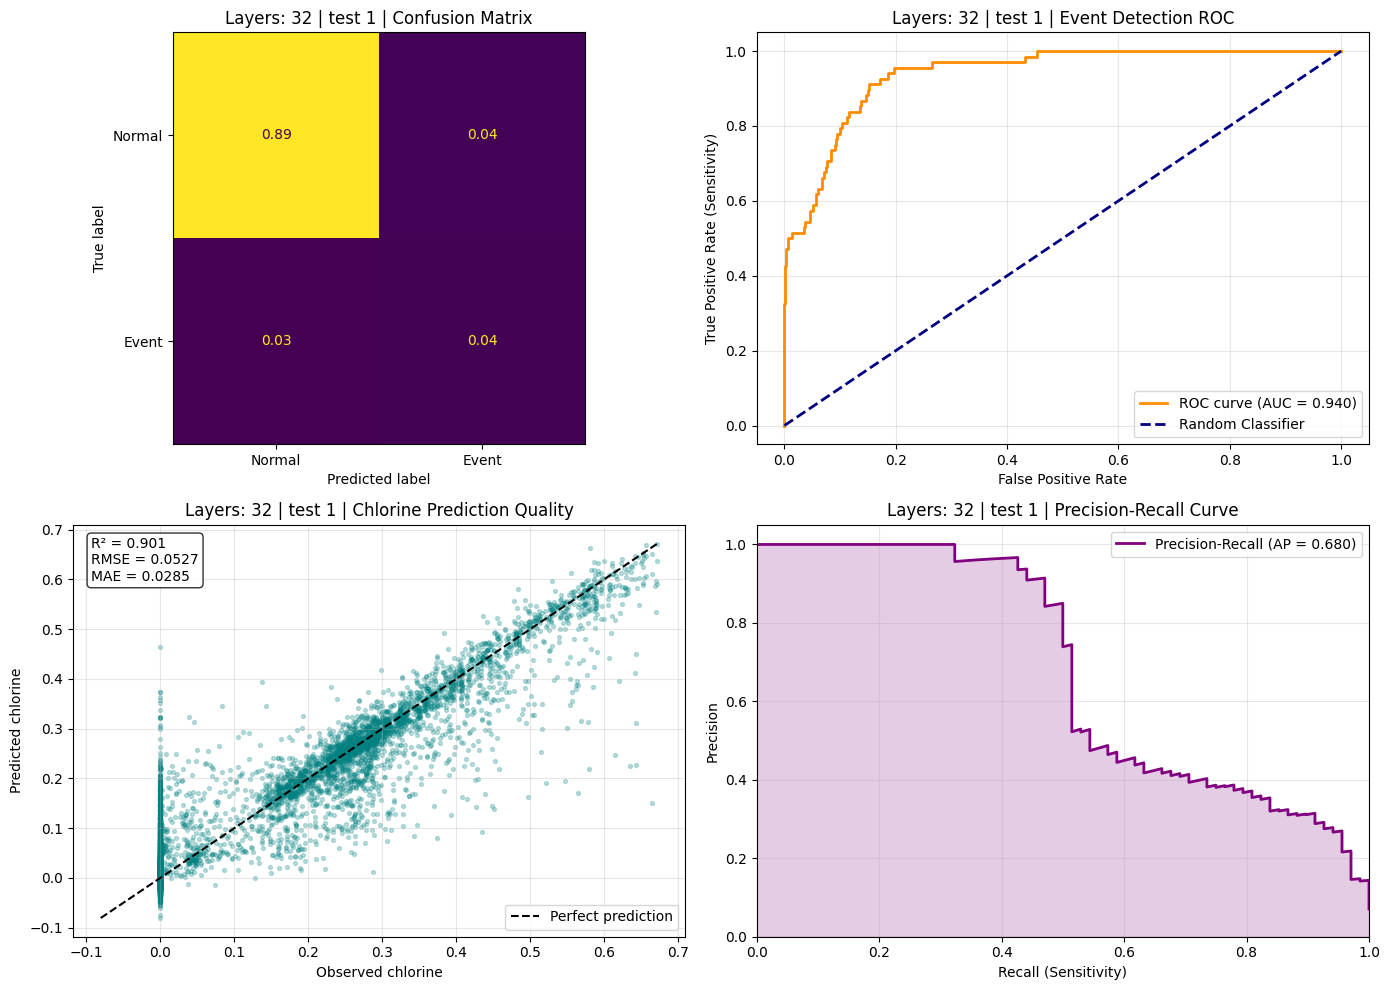

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


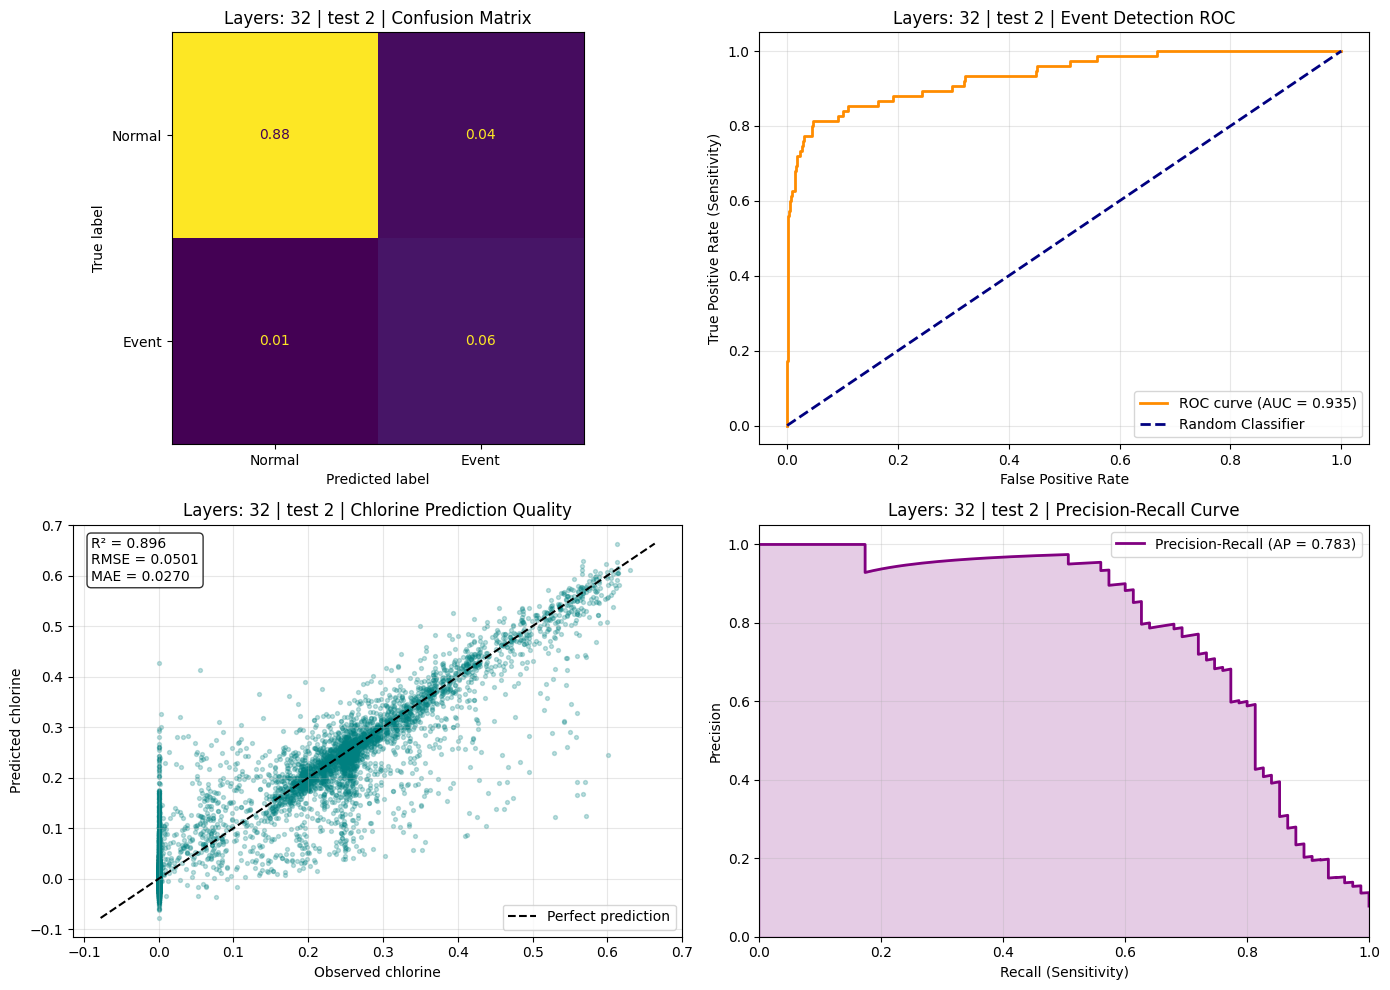

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


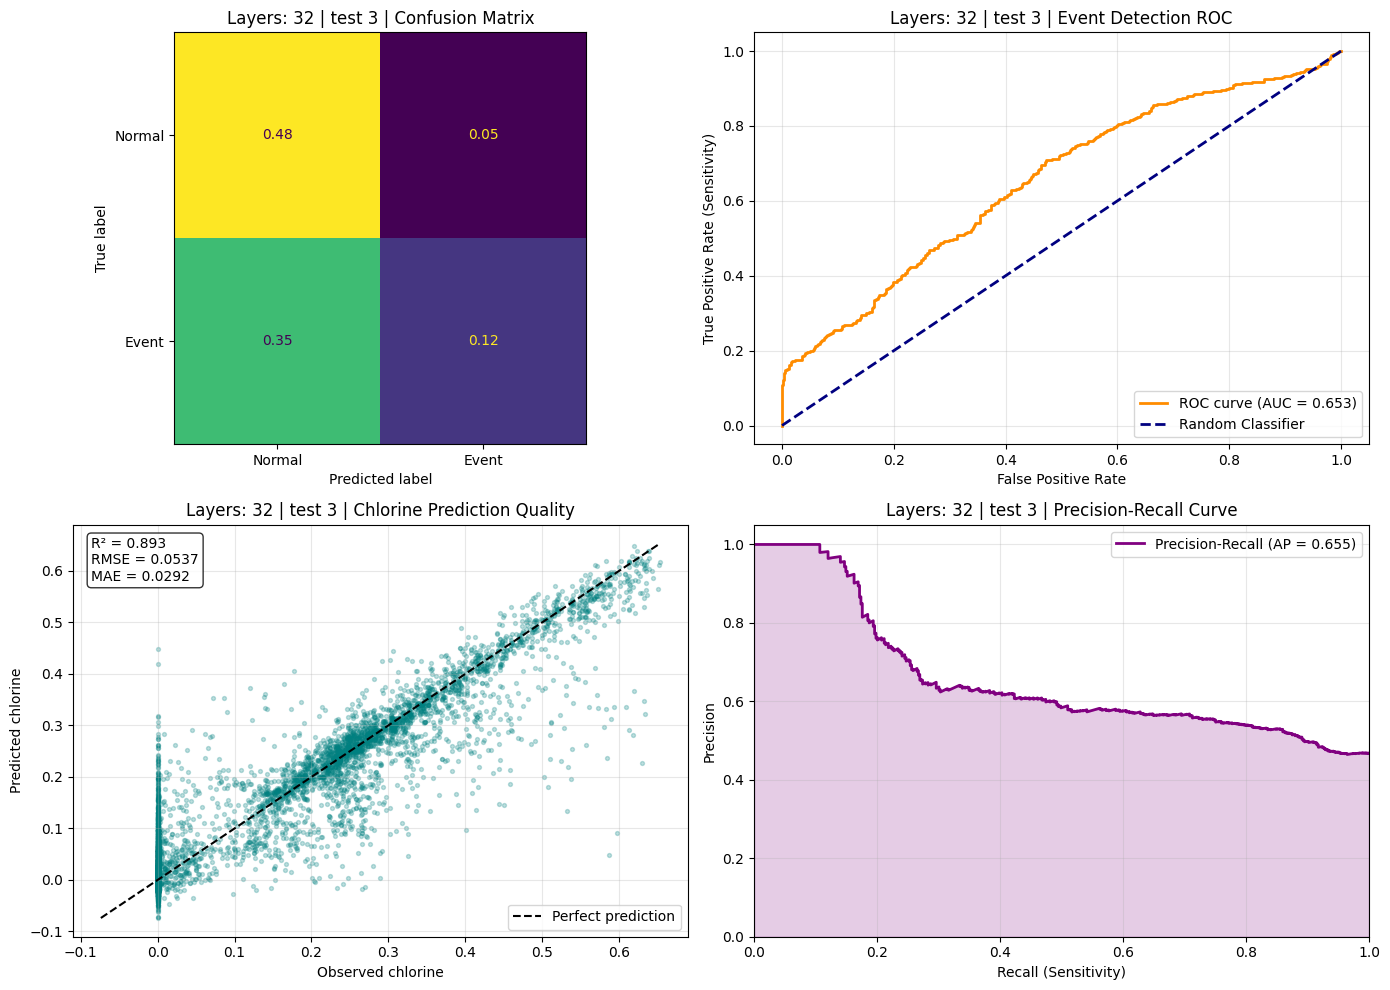

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


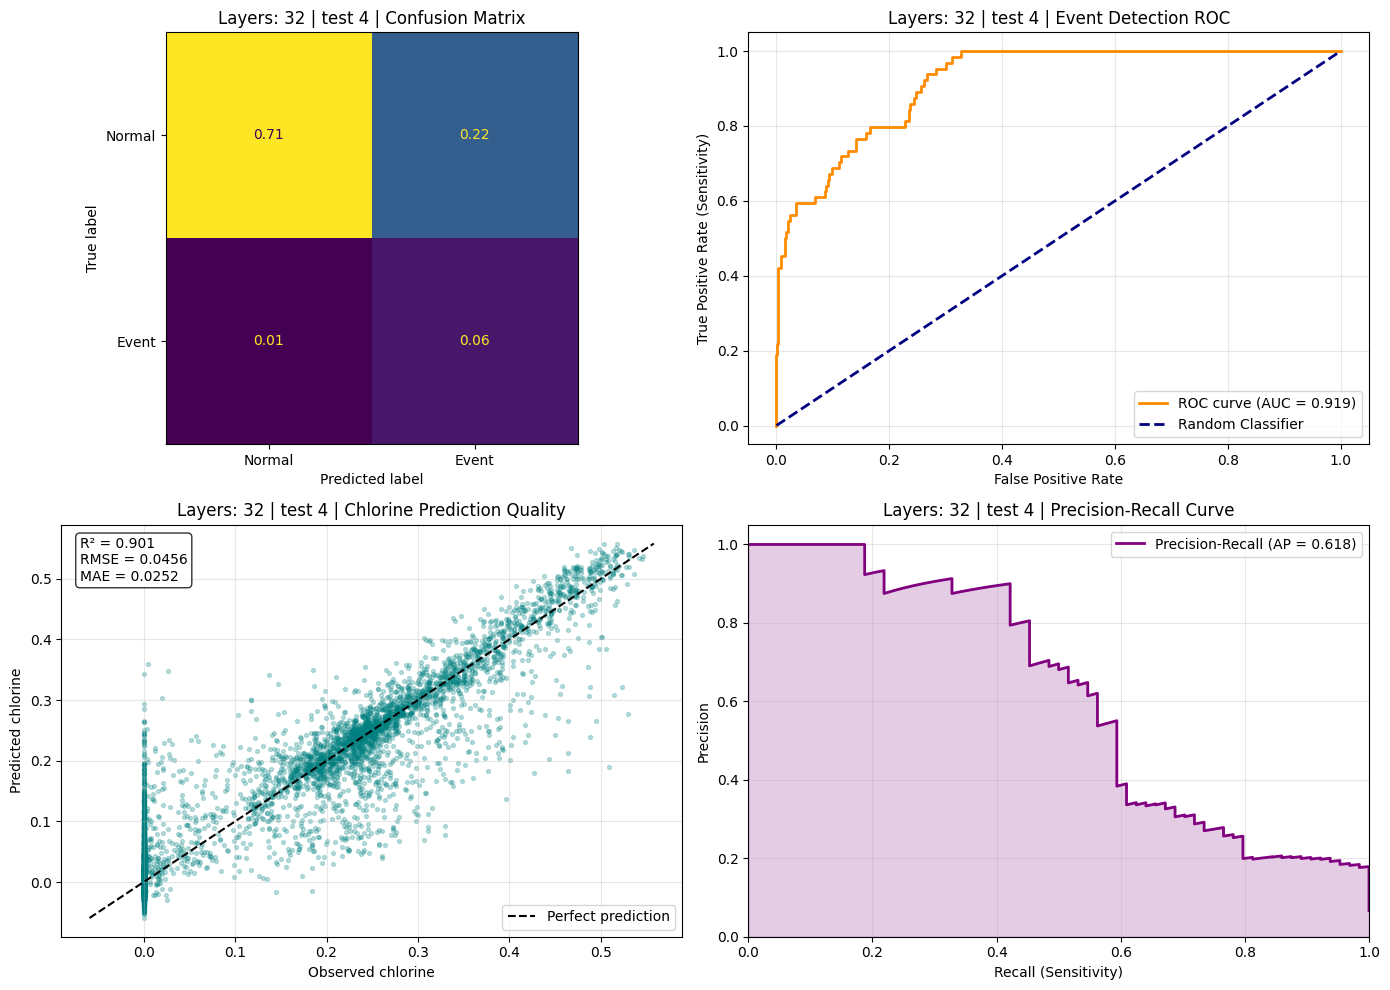


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/results/ANN/detector_strong_64-32/
Results for detector with hidden sizes: 64-32


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_strong_cont12.npz,0.486842,0.927159,0.544118,0.544118,0.043673,43200.0,76
scada_data_strong_cont13.npz,0.592233,0.941727,0.813333,0.813333,0.047404,1800.0,103
scada_data_strong_cont11.npz,0.706250,0.601457,0.251670,0.251670,0.091797,14400.0,160
scada_data_strong_cont10.npz,0.203774,0.770031,0.843750,0.843750,0.235229,0.0,265


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.497275,0.810094,0.613218,0.613218,0.104526,14850.000000,151.000000
std,0.215205,0.159338,0.276093,0.276093,0.089835,19956.202043,83.677954


Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


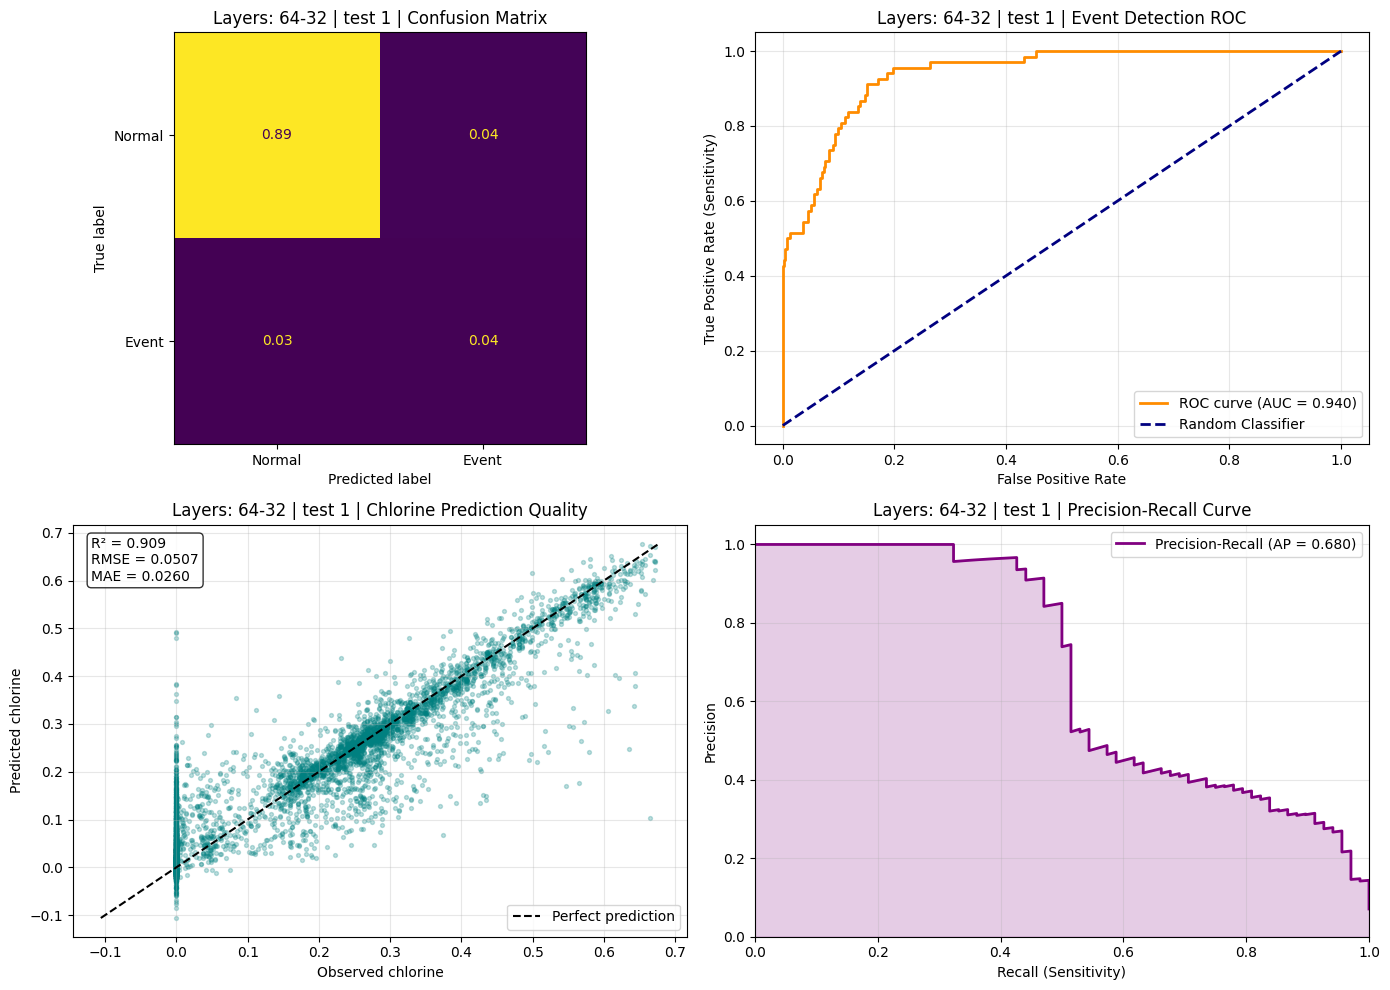

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


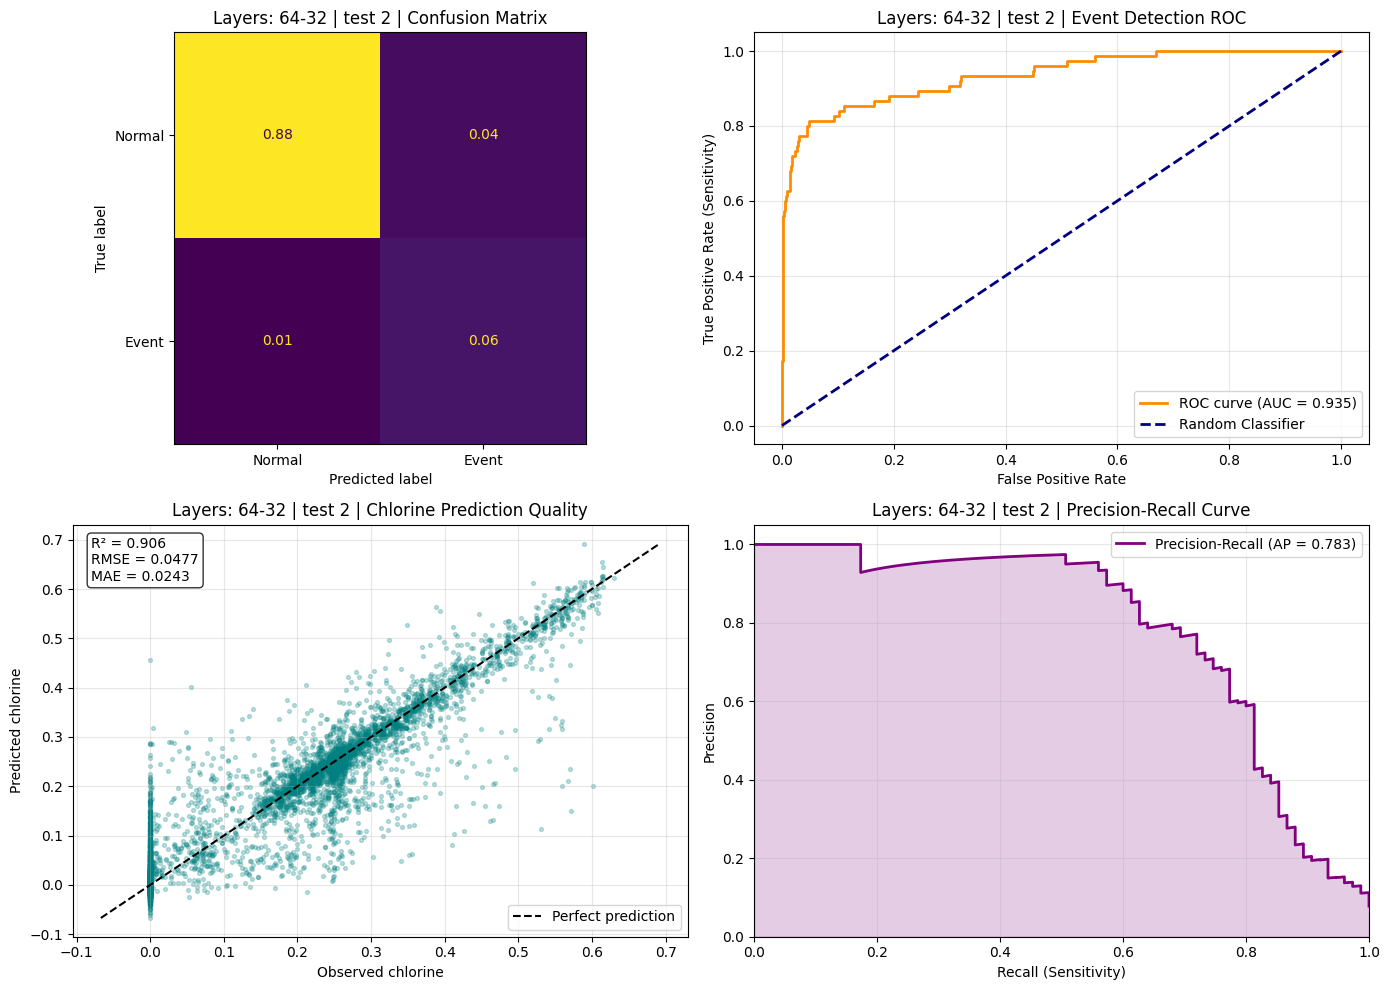

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


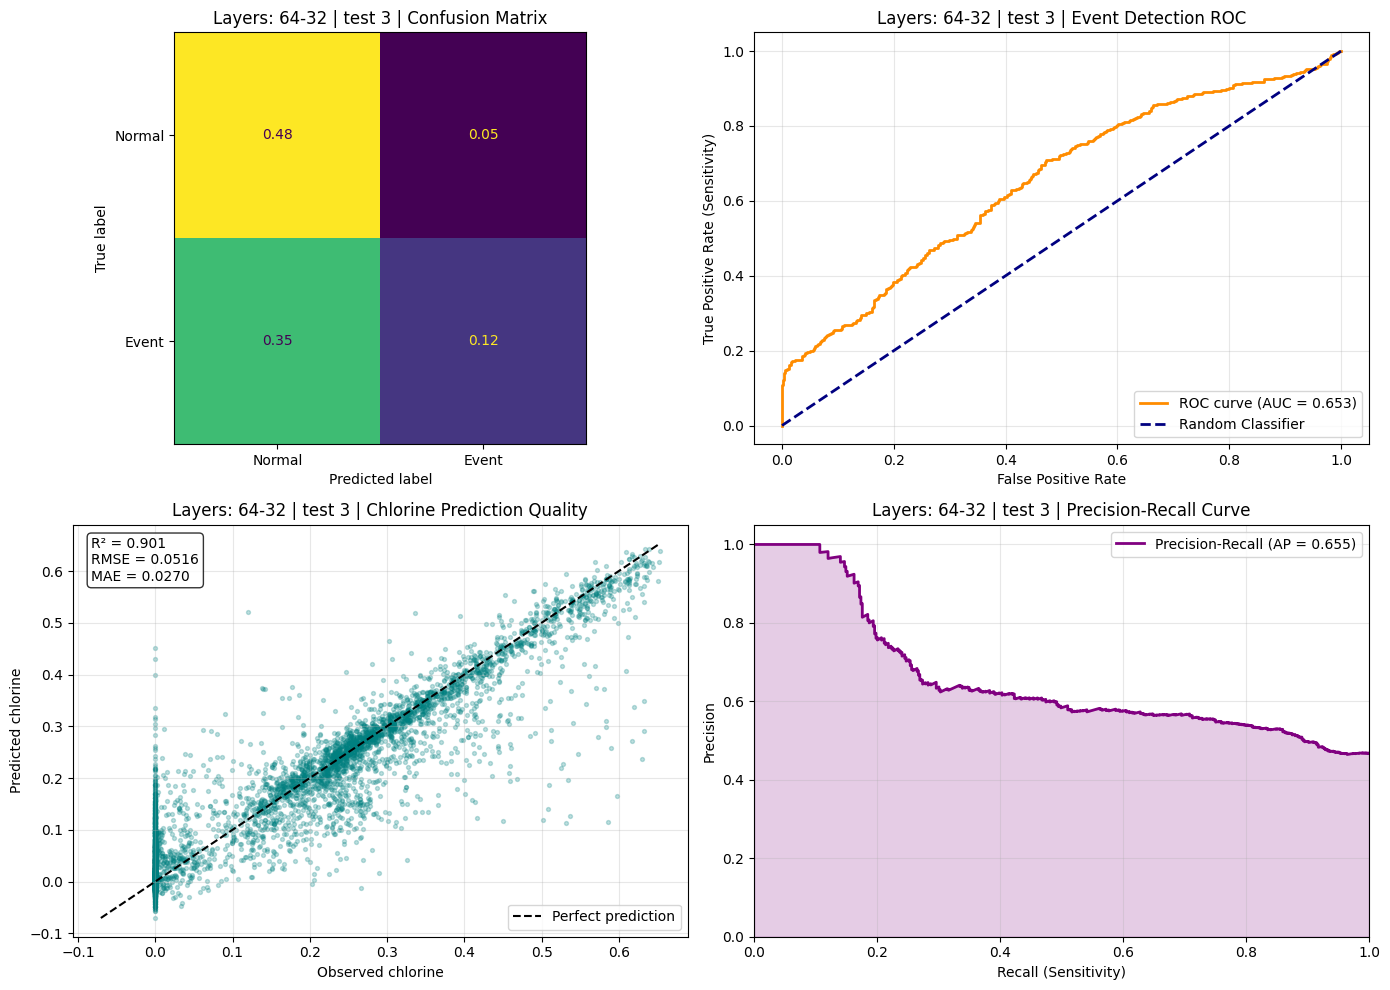

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


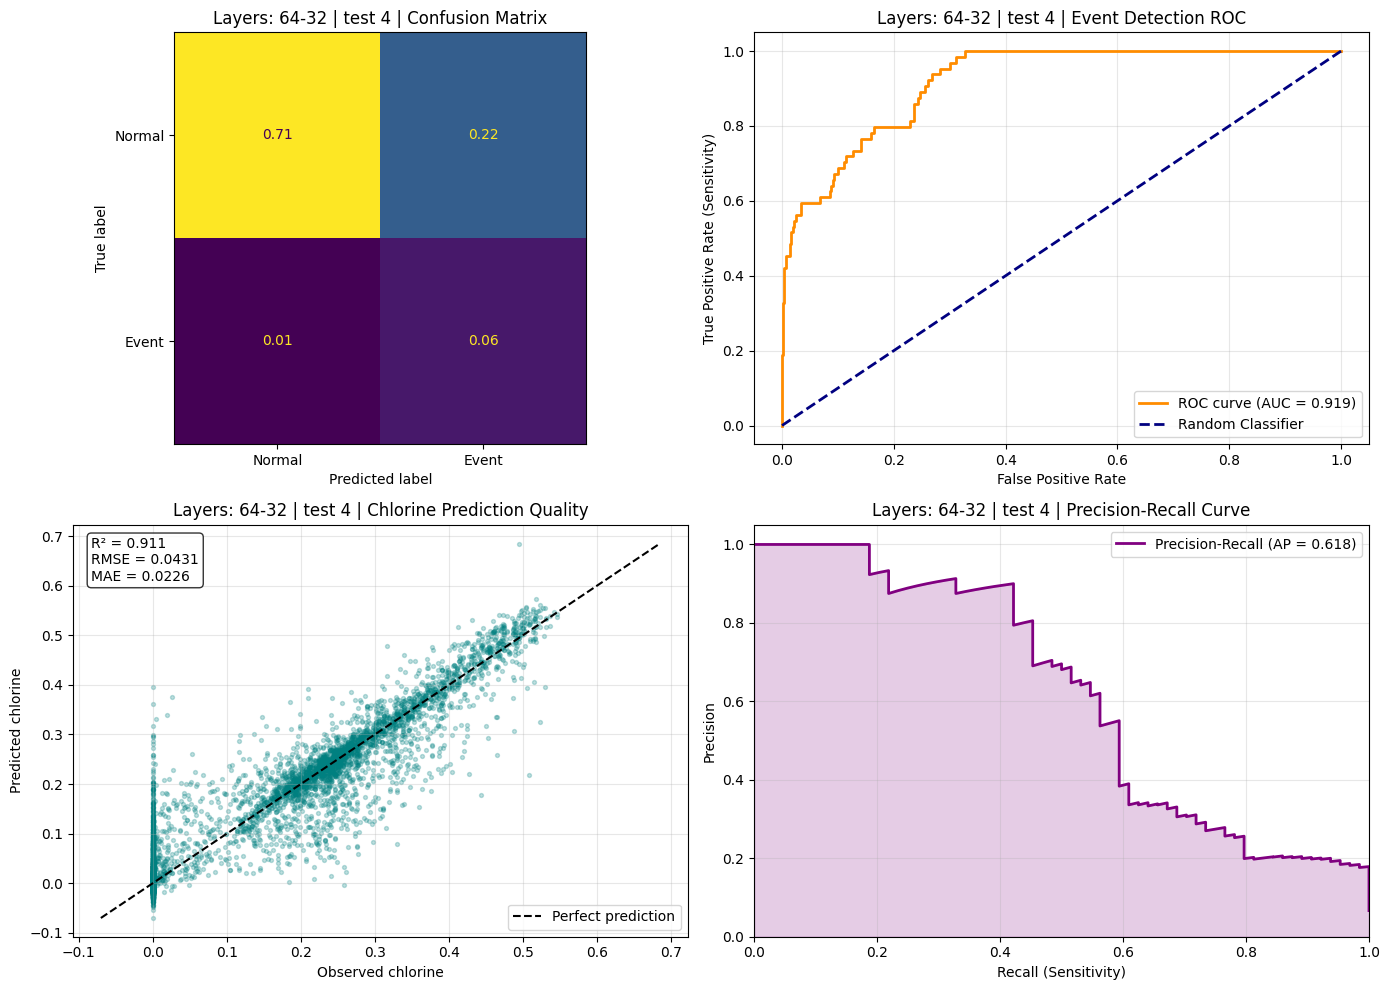


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/results/ANN/detector_strong_128-64/
Results for detector with hidden sizes: 128-64


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_strong_cont12.npz,0.486842,0.927159,0.544118,0.544118,0.043673,43200.0,76
scada_data_strong_cont13.npz,0.592233,0.941727,0.813333,0.813333,0.047404,1800.0,103
scada_data_strong_cont11.npz,0.706250,0.601457,0.251670,0.251670,0.091797,14400.0,160
scada_data_strong_cont10.npz,0.203774,0.770031,0.843750,0.843750,0.235229,0.0,265


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.497275,0.810094,0.613218,0.613218,0.104526,14850.000000,151.000000
std,0.215205,0.159338,0.276093,0.276093,0.089835,19956.202043,83.677954


Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


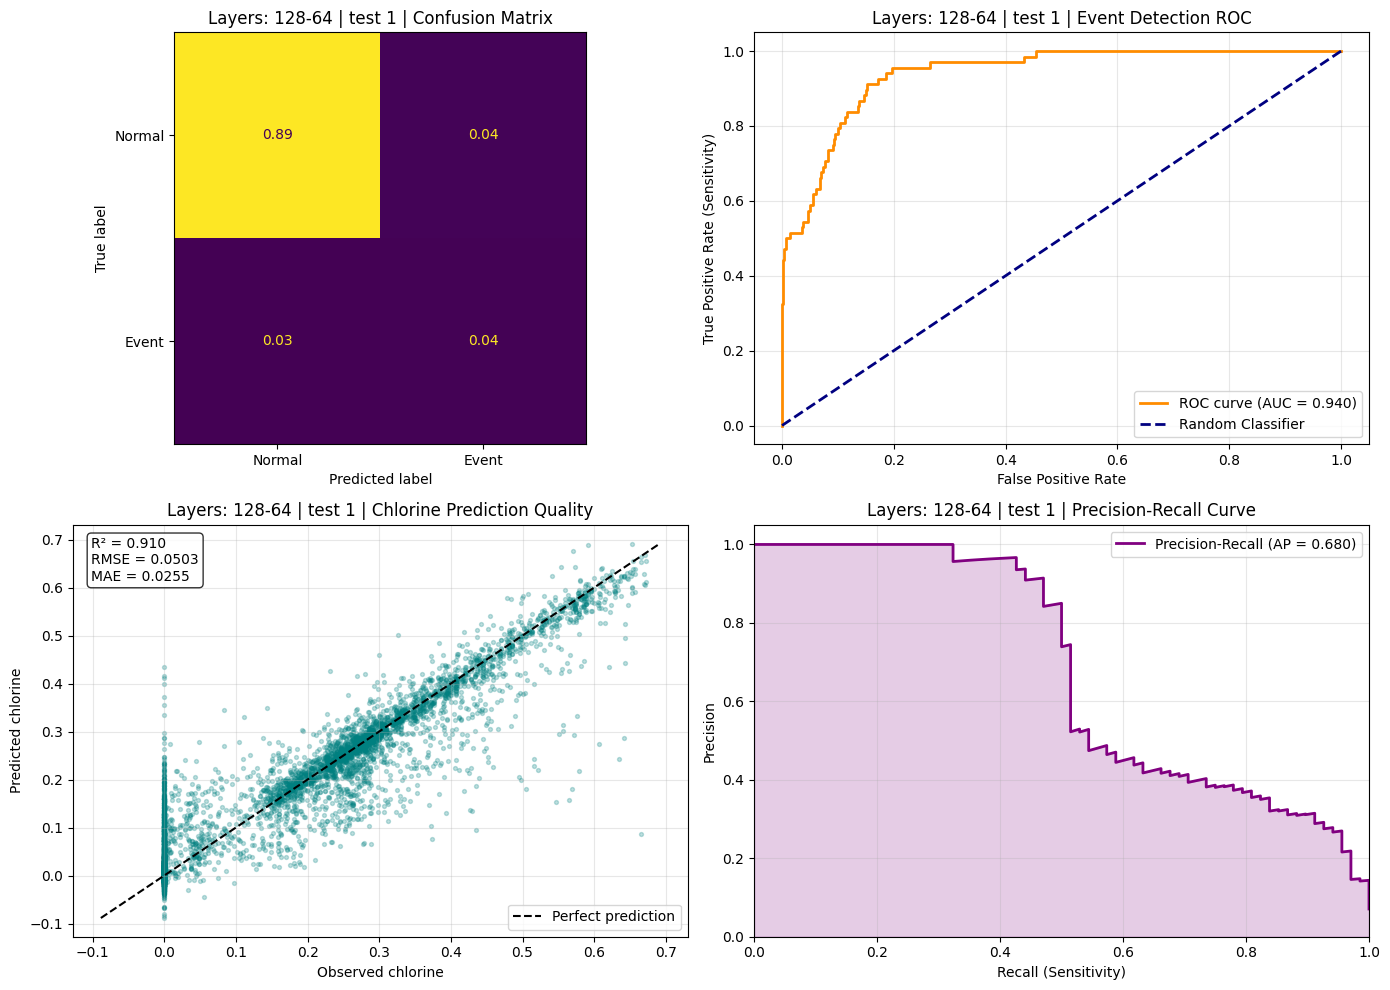

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


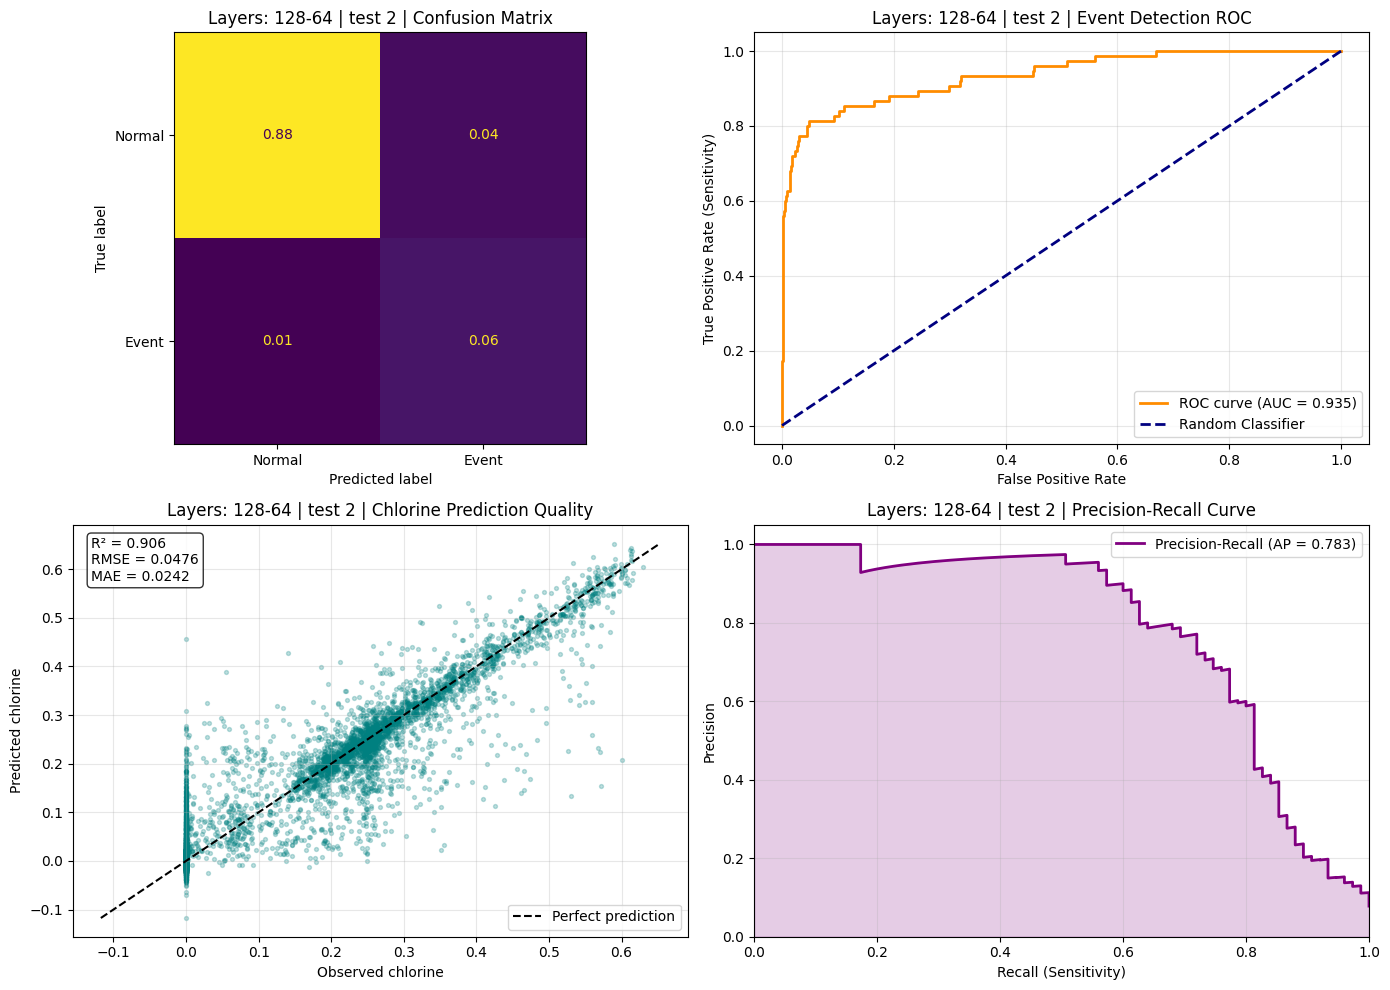

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


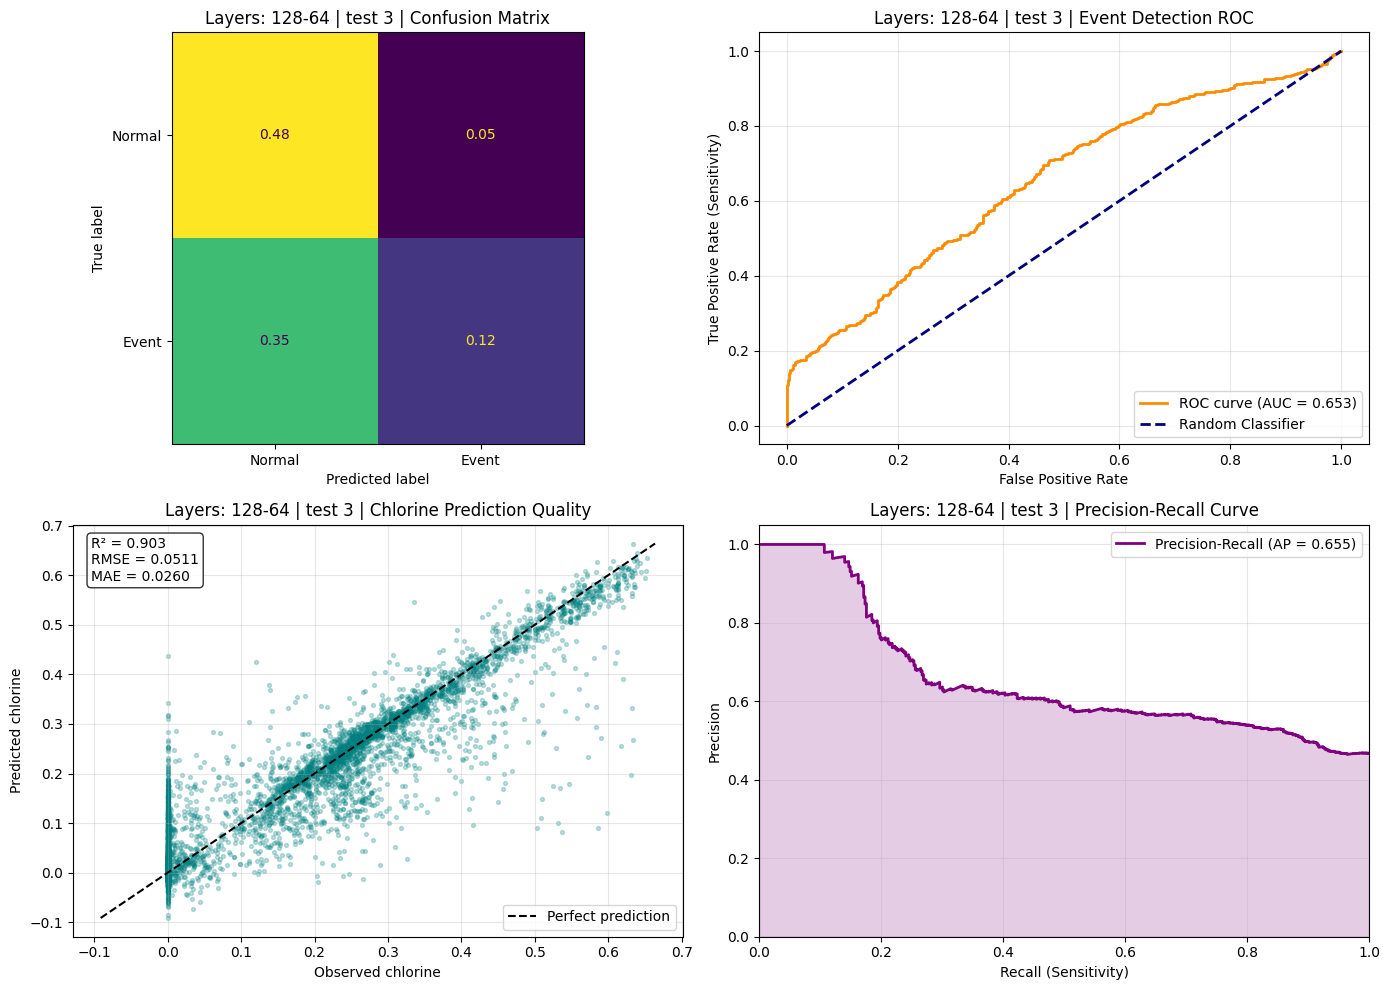

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


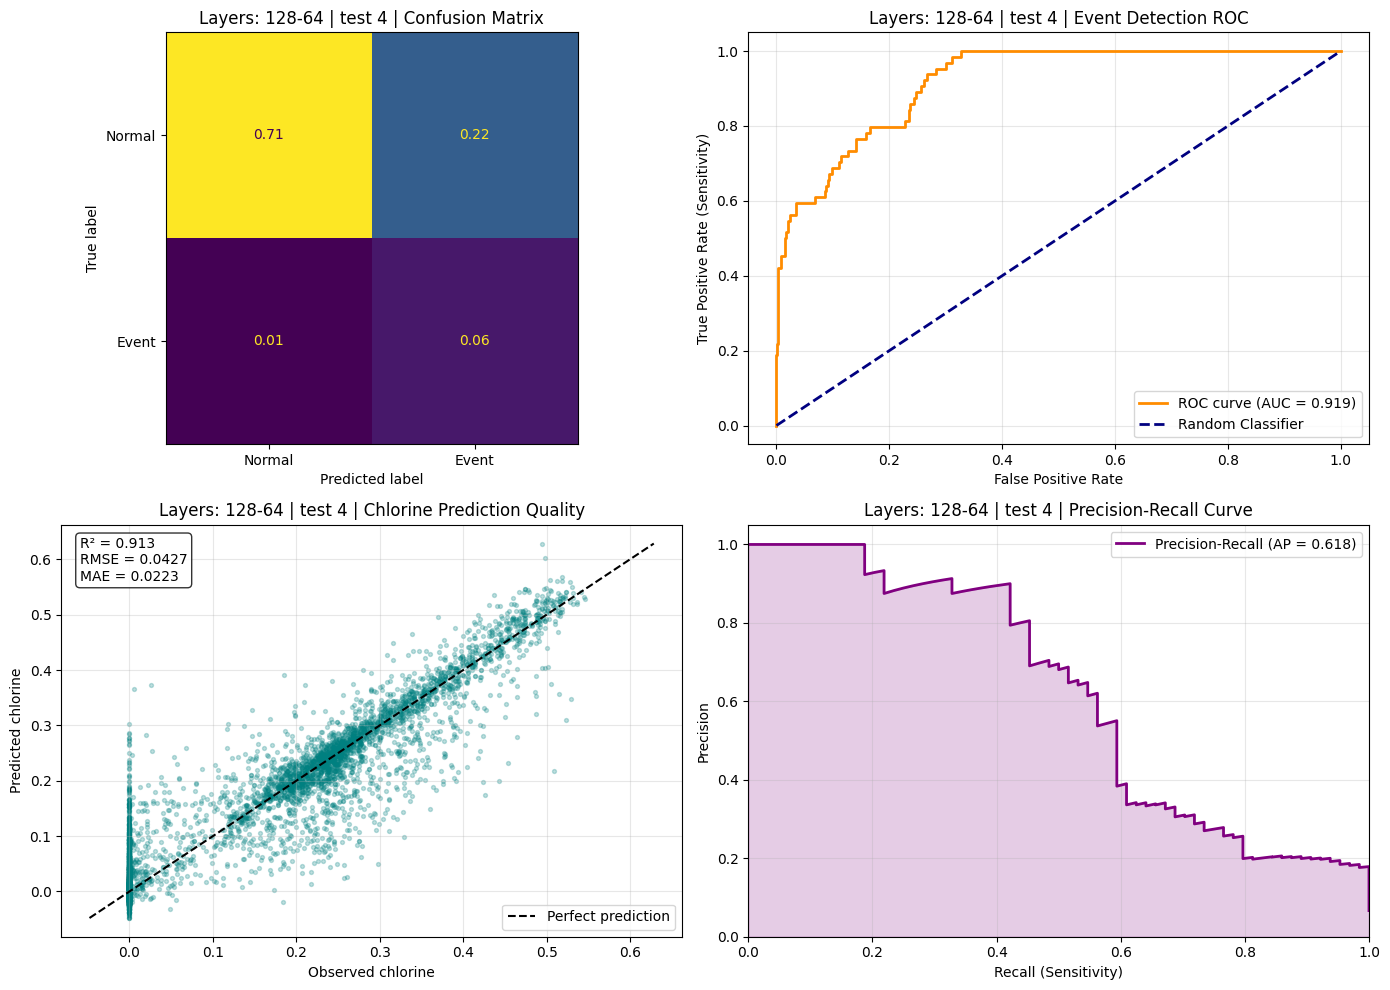


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/results/ANN/detector_strong_128-64-32/
Results for detector with hidden sizes: 128-64-32


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_strong_cont12.npz,0.486842,0.927159,0.544118,0.544118,0.043673,43200.0,76
scada_data_strong_cont13.npz,0.592233,0.941727,0.813333,0.813333,0.047404,1800.0,103
scada_data_strong_cont11.npz,0.706250,0.601457,0.251670,0.251670,0.091797,14400.0,160
scada_data_strong_cont10.npz,0.203774,0.770031,0.843750,0.843750,0.235229,0.0,265


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.497275,0.810094,0.613218,0.613218,0.104526,14850.000000,151.000000
std,0.215205,0.159338,0.276093,0.276093,0.089835,19956.202043,83.677954


Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


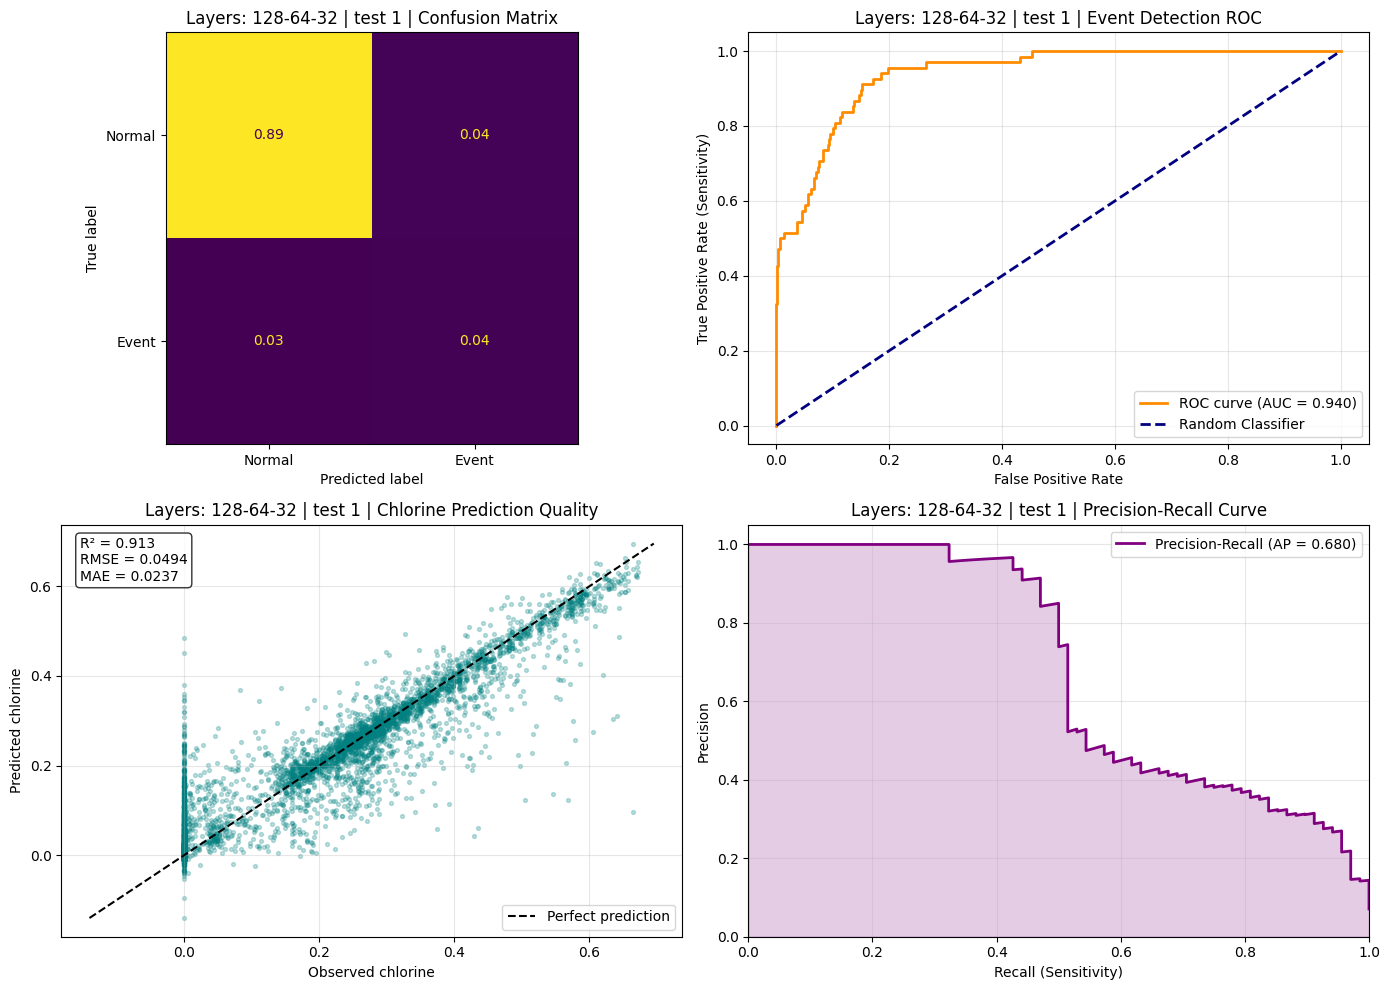

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


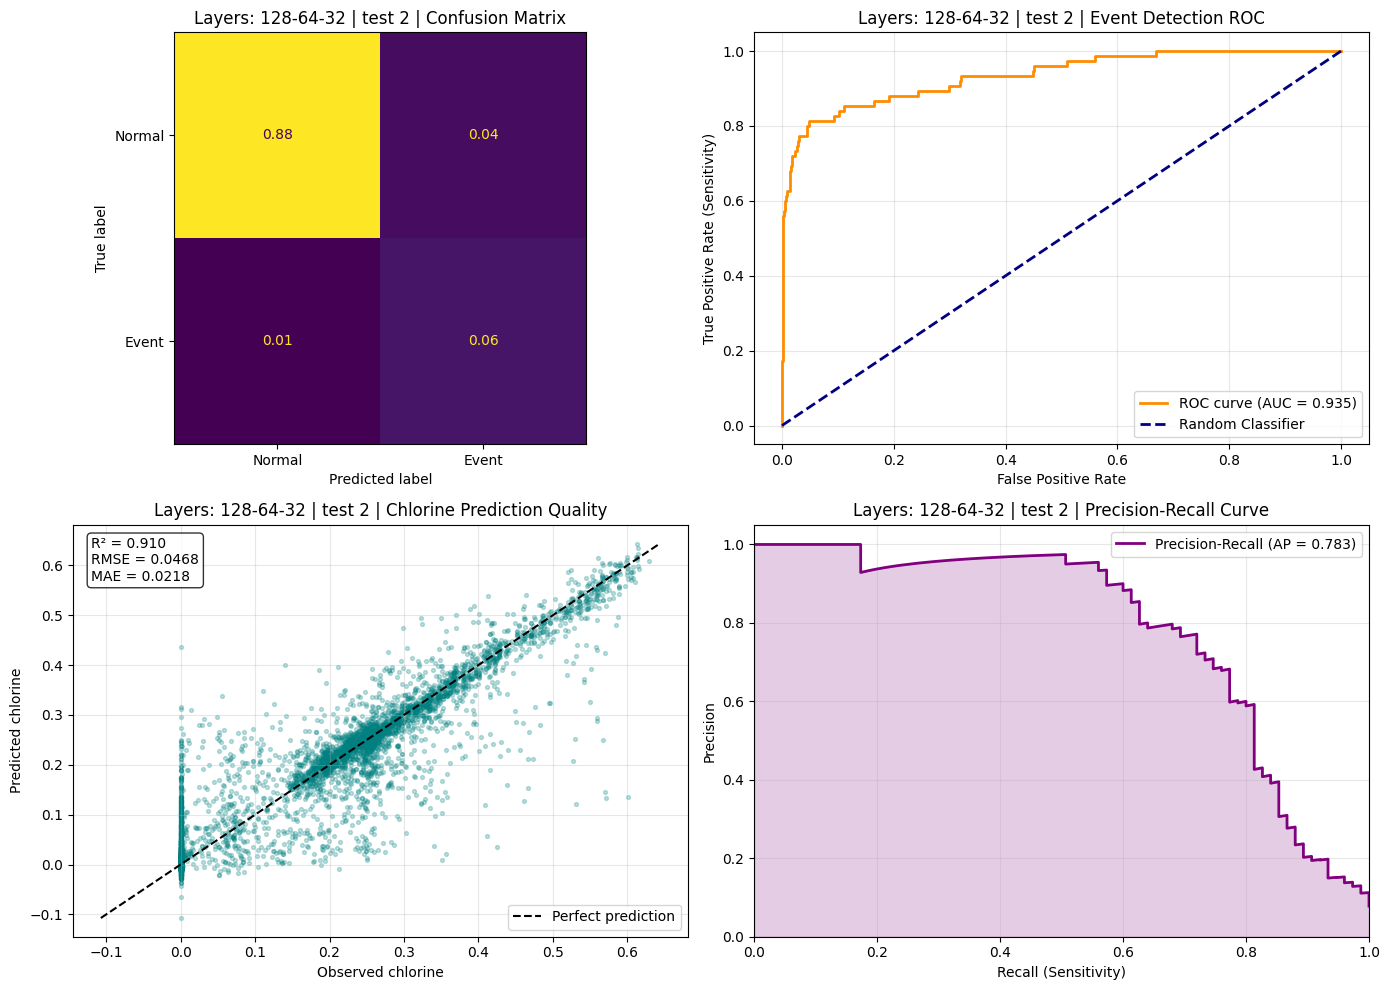

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


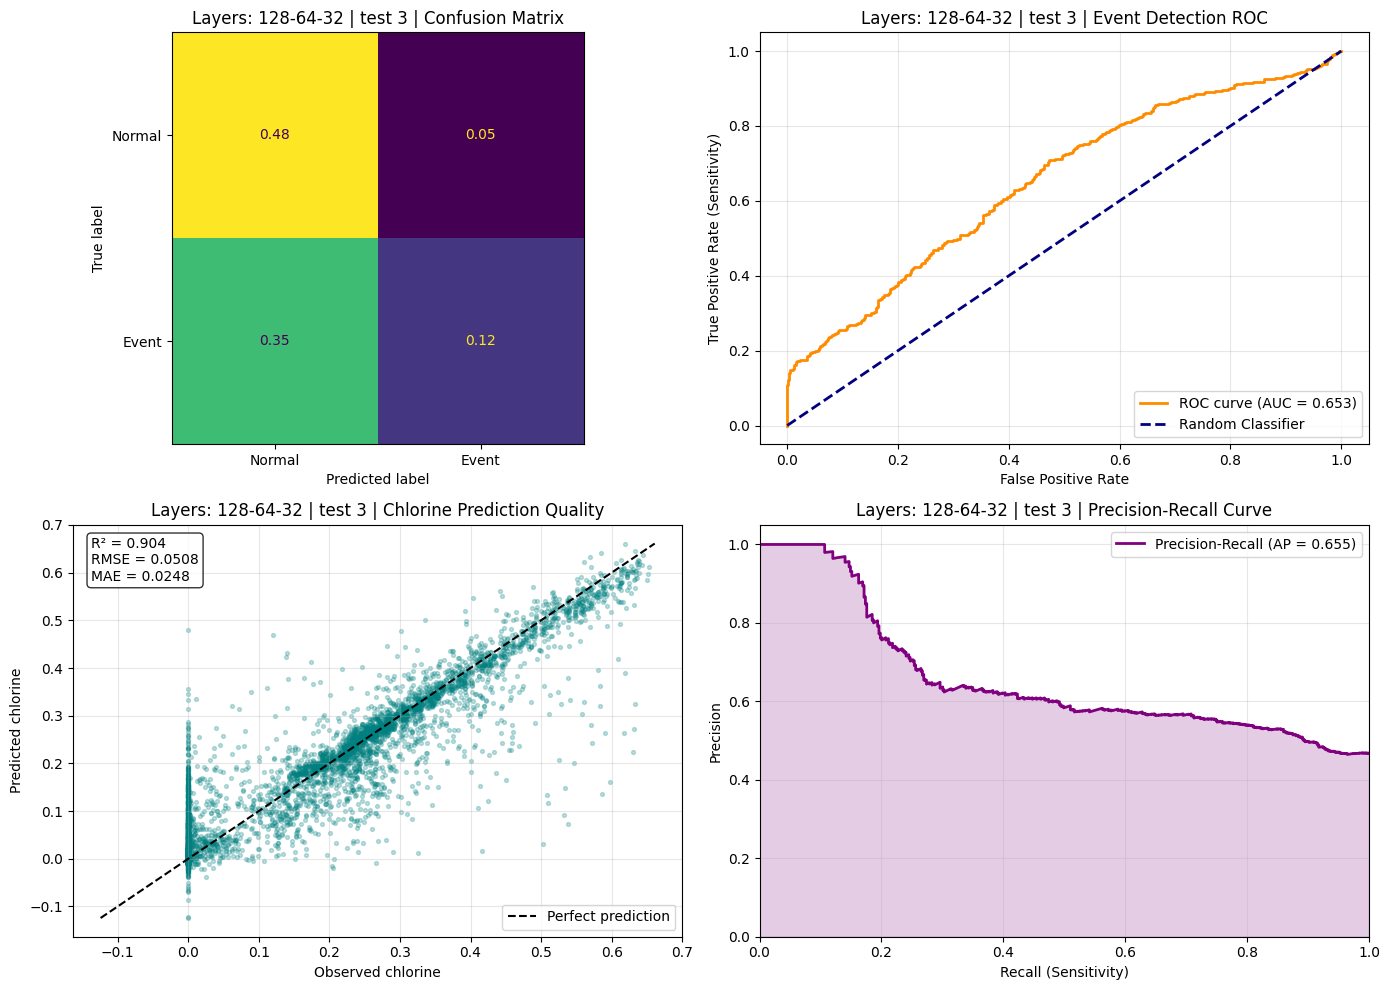

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


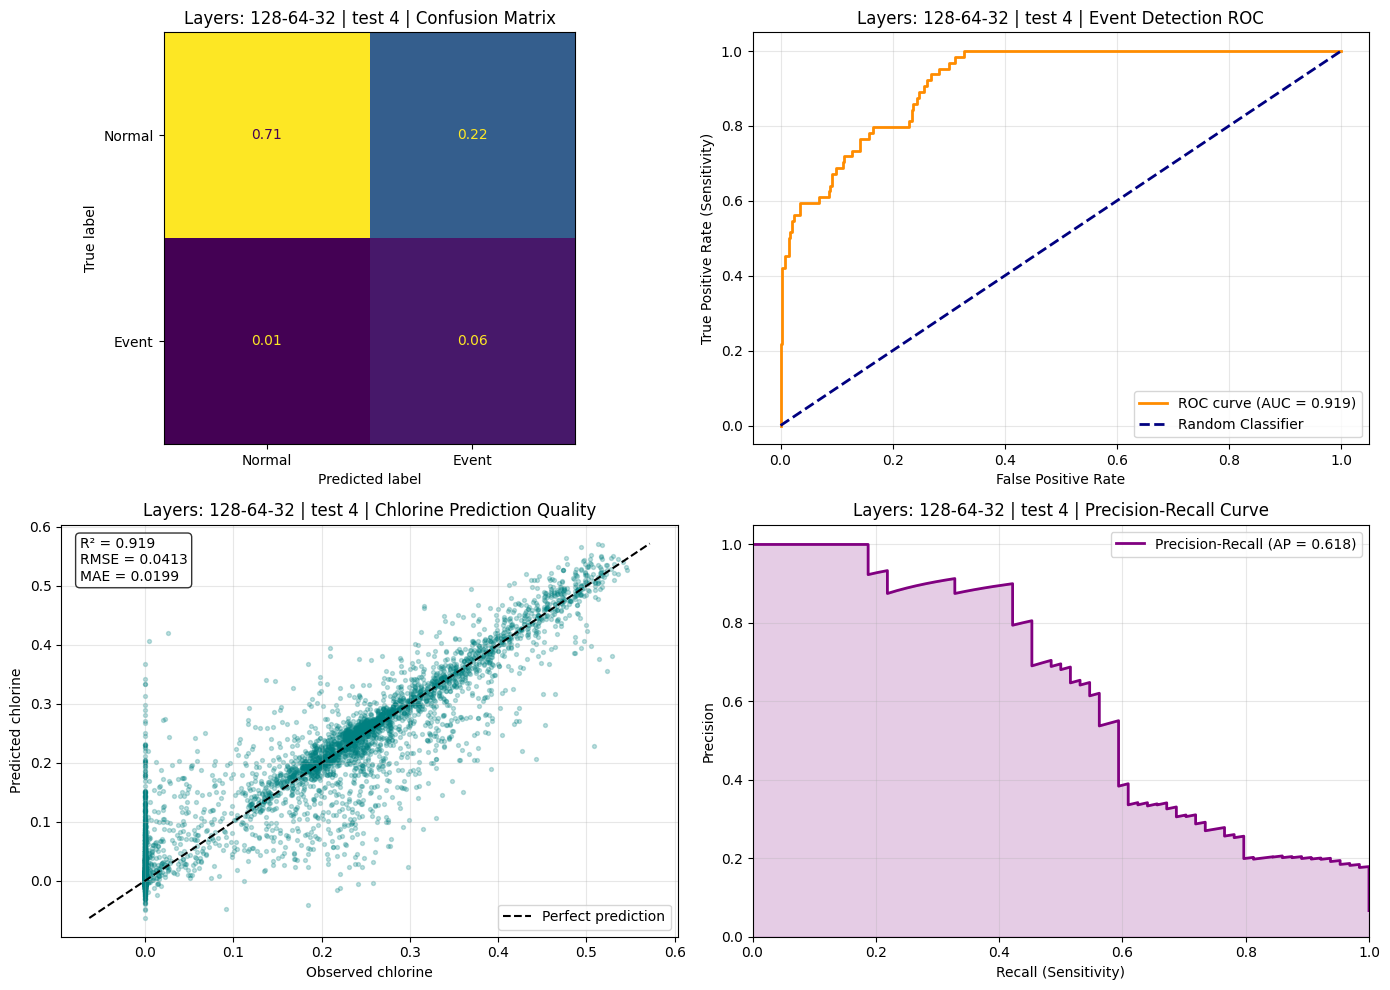

,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
hidden_sizes,,,,,,,
32,0.497275,0.810094,0.613218,0.613218,0.104526,14850.0,151.0
64-32,0.497275,0.810094,0.613218,0.613218,0.104526,14850.0,151.0
128-64,0.497275,0.810094,0.613218,0.613218,0.104526,14850.0,151.0
128-64-32,0.497275,0.810094,0.613218,0.613218,0.104526,14850.0,151.0


In [7]:
all_detector_summaries = []
# Use candidate_hidden_sizes to load all the saved detectors and run tests on them.
for hidden_sizes in candidate_hidden_sizes:
    hidden_sizes_label = "-".join(map(str, hidden_sizes))
    detector = load_detector(
        directory=f"../../results/ANN/detector_strong_{hidden_sizes_label}",
        device="mps",
    )

    selected_test_paths = test_paths
    results = [detector.detect(path) for path in selected_test_paths]

    print(f"Results for detector with hidden sizes: {hidden_sizes_label}")

    # Keep the four held-out test sets separated.
    summary_df = pd.DataFrame(
        [result.summary() for result in results],
        index=[path.name for path in selected_test_paths],
    )
    display(summary_df)

    # Aggregate metrics across the three test sets.
    aggregated_summary = pd.DataFrame(
        [
            summary_df.mean(numeric_only=True),
            summary_df.std(numeric_only=True),
        ],
        index=["mean", "std"],
    )
    display(aggregated_summary)

    detector_summary = summary_df.mean(numeric_only=True).to_dict()
    detector_summary["hidden_sizes"] = hidden_sizes_label
    all_detector_summaries.append(detector_summary)

    # Plot each test set separately, because each DetectionResult has its own timeline.
    for i, result in enumerate(results):
        plot_metrics(
            result,
            title_prefix=f"Layers: {hidden_sizes_label} | test {i+1} | ",
            chlorine_indices=list(range(result.actual.shape[1]))
        )

# Compare all detectors by their mean metrics.
all_detector_summaries_df = pd.DataFrame(all_detector_summaries).set_index("hidden_sizes")
display(all_detector_summaries_df)

In [8]:
import random

# Plot the best detector with selected chlorine sensor combinations
# detector = load_detector(
#     directory="../results/supervised_ann_detector",
#     device="mps",
# )

#generate 3 random combinations of 3 chlorine output channels
# chlorine_sensor_count = len(detector.target_scalers)
# chlorine_indices_combinations = [random.sample(range(chlorine_sensor_count), 3) for _ in range(3)]

# for chlorine_indices in chlorine_indices_combinations:
#     selected_test_paths = test_paths[:3]
#     results = [detector.detect(path) for path in selected_test_paths]

#     print(f"Results for detector with hidden sizes: {hidden_sizes_label}")

#     # Keep the three test sets separated.
#     summary_df = pd.DataFrame(
#         [result.summary() for result in results],
#         index=[path.name for path in selected_test_paths],
#     )
#     display(summary_df)

#     # Aggregate metrics across the three test sets.
#     aggregated_summary = pd.DataFrame(
#         [
#             summary_df.mean(numeric_only=True),
#             summary_df.std(numeric_only=True),
#         ],
#         index=["mean", "std"],
#     )
#     display(aggregated_summary)

#     detector_summary = summary_df.mean(numeric_only=True).to_dict()
#     detector_summary["hidden_sizes"] = hidden_sizes_label
#     all_detector_summaries.append(detector_summary)

#     # Plot each test set separately, because each DetectionResult has its own timeline.
#     for i, result in enumerate(results):
#         plot_metrics(
#             result,
#             title_prefix=f"Layers: {hidden_sizes_label} | test {i+1} | ",
#             chlorine_indices=chlorine_indices
#         )